# Chronic Kidney Disease — Data Exploration and Cleaning

This notebook loads the official UCI Chronic Kidney Disease ARFF file, explores its quality, cleans inconsistent values, validates the variables, creates report figures, and saves a processed CSV for model training.

**Source:** UCI Machine Learning Repository, Chronic Kidney Disease (Dataset ID 336)  
**License:** Creative Commons Attribution 4.0 International (CC BY 4.0)

In [1]:
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff


# Configure chart appearance
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Locate the project root whether the notebook starts from
# the project folder or the notebooks folder
current_folder = Path.cwd()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

# Build the required project paths
raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "chronic_kidney_disease_full.arff"
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "kidney_disease_clean.csv"
)

figures_folder = (
    project_root
    / "reports"
    / "figures"
)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Dataset path:", raw_data_path)
print("File exists:", raw_data_path.exists())

if not raw_data_path.exists():
    raise FileNotFoundError(
        "Place chronic_kidney_disease_full.arff inside data/raw."
    )

Dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\chronic_kidney_disease_full.arff
File exists: True


In [2]:
# Load and repair the official UCI ARFF dataset before parsing.
# The source file contains inconsistent spaces/tabs in some categorical values.

raw_text = raw_data_path.read_text(
    encoding="utf-8",
    errors="replace"
)

normalized_lines = []
inside_data_section = False
repaired_rows = 0

for raw_line in raw_text.splitlines():

    stripped_line = raw_line.strip()

    # Detect the start of the ARFF data section
    if stripped_line.lower() == "@data":
        inside_data_section = True
        normalized_lines.append("@data")
        continue

    # Clean actual data rows
    if (
        inside_data_section
        and stripped_line
        and not stripped_line.startswith("%")
    ):

        cleaned_fields = [
            field.strip() if field.strip() else "?"
            for field in raw_line.split(",")
        ]

        # Some source rows may contain accidental empty fields at the end
        while (
            len(cleaned_fields) > 25
            and cleaned_fields[-1] == "?"
        ):
            cleaned_fields.pop()
            repaired_rows += 1

        # Repair malformed source row containing one extra field
        # before the appetite feature.
        if (
            len(cleaned_fields) == 26
            and cleaned_fields[-1] in {"ckd", "notckd"}
            and cleaned_fields[21] not in {"good", "poor", "?"}
        ):
            cleaned_fields.pop(21)
            repaired_rows += 1

        if len(cleaned_fields) != 25:
            raise ValueError(
                f"Unexpected ARFF field count: "
                f"{len(cleaned_fields)}"
            )

        normalized_lines.append(
            ",".join(cleaned_fields)
        )

    else:
        # Preserve ARFF header and comments
        normalized_lines.append(raw_line)


# Rebuild a clean ARFF representation in memory
normalized_arff = "\n".join(normalized_lines)

# Parse the cleaned ARFF
raw_records, dataset_metadata = arff.loadarff(
    io.StringIO(normalized_arff)
)

kidney_raw = pd.DataFrame(raw_records)


# Decode byte strings and normalize text values
object_columns = kidney_raw.select_dtypes(
    include="object"
).columns

for column in object_columns:

    kidney_raw[column] = kidney_raw[column].map(
        lambda value: (
            value.decode(
                "utf-8",
                errors="replace"
            )
            if isinstance(value, bytes)
            else value
        )
    )

    kidney_raw[column] = kidney_raw[column].map(
        lambda value: (
            value.strip()
            if isinstance(value, str)
            else value
        )
    )


print("Dataset loaded successfully.")
print("Repaired malformed ARFF rows:", repaired_rows)
print("Dataset shape:", kidney_raw.shape)

print("\nColumn names:")
print(kidney_raw.columns.tolist())

print("\nData types:")
print(kidney_raw.dtypes)

display(kidney_raw.head())

Dataset loaded successfully.
Repaired malformed ARFF rows: 3
Dataset shape: (400, 25)

Column names:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']

Data types:
age      float64
bp       float64
sg           str
al           str
su           str
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
class        str
dtype: object


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1,0,?,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4,0,?,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
# Summarize missing and duplicated records before cleaning
raw_quality_summary = pd.DataFrame(
    {
        "Data Type": kidney_raw.dtypes.astype(str),
        "Missing Values": kidney_raw.isnull().sum(),
        "Unique Values": kidney_raw.nunique(dropna=True)
    }
)

print("Raw data quality summary:")
display(
    raw_quality_summary.sort_values(
        "Missing Values",
        ascending=False
    )
)

print("Duplicated rows:", kidney_raw.duplicated().sum())
print("\nRaw target distribution:")
print(kidney_raw["class"].value_counts(dropna=False))

Raw data quality summary:


,Data Type,Missing Values,Unique Values
rbcc,float64,131,45
wbcc,float64,106,89
pot,float64,88,40
sod,float64,87,34
pcv,float64,71,42
hemo,float64,52,115
bgr,float64,44,146
bu,float64,19,118
sc,float64,17,84
bp,float64,12,10


Duplicated rows: 0

Raw target distribution:
class
ckd       250
notckd    150
Name: count, dtype: int64


In [4]:
# Display raw categorical values with visible Python representations
raw_categorical_columns = kidney_raw.select_dtypes(
    include="object"
).columns.tolist()

for column in raw_categorical_columns:
    represented_values = [
        repr(value)
        for value in kidney_raw[column].dropna().unique()
    ]
    print(f"{column}: {represented_values}")

sg: ["'1.020'", "'1.010'", "'1.005'", "'1.015'", "'?'", "'1.025'"]
al: ["'1'", "'4'", "'2'", "'3'", "'0'", "'?'", "'5'"]
su: ["'0'", "'3'", "'4'", "'1'", "'?'", "'2'", "'5'"]
rbc: ["'?'", "'normal'", "'abnormal'"]
pc: ["'normal'", "'abnormal'", "'?'"]
pcc: ["'notpresent'", "'present'", "'?'"]
ba: ["'notpresent'", "'present'", "'?'"]
htn: ["'yes'", "'no'", "'?'"]
dm: ["'yes'", "'no'", "'?'"]
cad: ["'no'", "'yes'", "'?'"]
appet: ["'good'", "'poor'", "'?'"]
pe: ["'no'", "'yes'", "'?'"]
ane: ["'no'", "'yes'", "'?'"]
class: ["'ckd'", "'notckd'"]


C:\Users\20247\AppData\Local\Temp\ipykernel_17824\433219854.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  raw_categorical_columns = kidney_raw.select_dtypes(


## Cleaning strategy

- Strip whitespace and tab characters from column names and text values.
- Convert explicit question marks and empty strings to missing values.
- Convert the documented numerical variables to numeric values.
- Normalize categorical spelling and create a binary target.
- Preserve missing values for later imputation inside the training pipeline to prevent data leakage.

In [5]:
# Create an independent working copy
kidney_clean = kidney_raw.copy()

# Normalize column names
kidney_clean.columns = [
    str(column).strip().lower()
    for column in kidney_clean.columns
]

# Strip whitespace and normalize explicit missing markers
for column in kidney_clean.select_dtypes(include="object").columns:
    kidney_clean[column] = kidney_clean[column].map(
        lambda value: (
            value.strip().lower()
            if isinstance(value, str)
            else value
        )
    )

    kidney_clean[column] = kidney_clean[column].replace(
        {
            "": np.nan,
            "?": np.nan
        }
    )

# Define the documented numerical variables
numerical_columns = [
    "age",
    "bp",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc"
]

# Support alternative UCI abbreviations when present
column_aliases = {
    "wc": "wbcc",
    "rc": "rbcc"
}

kidney_clean = kidney_clean.rename(columns=column_aliases)

for column in numerical_columns:
    if column in kidney_clean.columns:
        kidney_clean[column] = pd.to_numeric(
            kidney_clean[column],
            errors="coerce"
        )

# Define the documented categorical variables
categorical_columns = [
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane"
]

# Convert the original class labels to a binary target
target_mapping = {
    "notckd": 0,
    "ckd": 1
}

kidney_clean["kidney_disease"] = (
    kidney_clean["class"].map(target_mapping)
)

if kidney_clean["kidney_disease"].isnull().any():
    invalid_targets = kidney_clean.loc[
        kidney_clean["kidney_disease"].isnull(),
        "class"
    ].unique()
    raise ValueError(f"Unexpected target labels: {invalid_targets}")

kidney_clean["kidney_disease"] = kidney_clean["kidney_disease"].astype("int8")
kidney_clean = kidney_clean.drop(columns=["class"])

print("Cleaned dataset shape:", kidney_clean.shape)
display(kidney_clean.head())

Cleaned dataset shape: (400, 25)


C:\Users\20247\AppData\Local\Temp\ipykernel_17824\686018001.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in kidney_clean.select_dtypes(include="object").columns:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,kidney_disease
0,48.0,80.0,1.020,1,0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [6]:
# Validate categorical values against the dataset documentation
expected_categories = {
    "sg": {1.005, 1.010, 1.015, 1.020, 1.025, "1.005", "1.010", "1.015", "1.020", "1.025"},
    "al": {0, 1, 2, 3, 4, 5, "0", "1", "2", "3", "4", "5"},
    "su": {0, 1, 2, 3, 4, 5, "0", "1", "2", "3", "4", "5"},
    "rbc": {"normal", "abnormal"},
    "pc": {"normal", "abnormal"},
    "pcc": {"present", "notpresent"},
    "ba": {"present", "notpresent"},
    "htn": {"yes", "no"},
    "dm": {"yes", "no"},
    "cad": {"yes", "no"},
    "appet": {"good", "poor"},
    "pe": {"yes", "no"},
    "ane": {"yes", "no"}
}

unexpected_categories = {}

for column, allowed_values in expected_categories.items():
    if column not in kidney_clean.columns:
        unexpected_categories[column] = ["COLUMN MISSING"]
        continue

    observed_values = set(kidney_clean[column].dropna().unique())
    invalid_values = observed_values - allowed_values

    if invalid_values:
        unexpected_categories[column] = sorted(
            [str(value) for value in invalid_values]
        )

print("Unexpected categorical values:", unexpected_categories)

# Build the final feature summary
feature_summary = pd.DataFrame(
    {
        "Data Type": kidney_clean.dtypes.astype(str),
        "Missing Values": kidney_clean.isnull().sum(),
        "Missing Percentage": (
            kidney_clean.isnull().mean().mul(100).round(2)
        ),
        "Unique Values": kidney_clean.nunique(dropna=True)
    }
)

display(
    feature_summary.sort_values(
        "Missing Values",
        ascending=False
    )
)

print("Duplicated cleaned rows:", kidney_clean.duplicated().sum())
print("\nClean target distribution:")
print(kidney_clean["kidney_disease"].value_counts().sort_index())

Unexpected categorical values: {}


,Data Type,Missing Values,Missing Percentage,Unique Values
rbc,str,152,38.00,2
rbcc,float64,131,32.75,45
wbcc,float64,106,26.50,89
pot,float64,88,22.00,40
sod,float64,87,21.75,34
pcv,float64,71,17.75,42
pc,str,65,16.25,2
hemo,float64,52,13.00,115
su,str,49,12.25,6
sg,str,47,11.75,5


Duplicated cleaned rows: 0

Clean target distribution:
kidney_disease
0    150
1    250
Name: count, dtype: int64


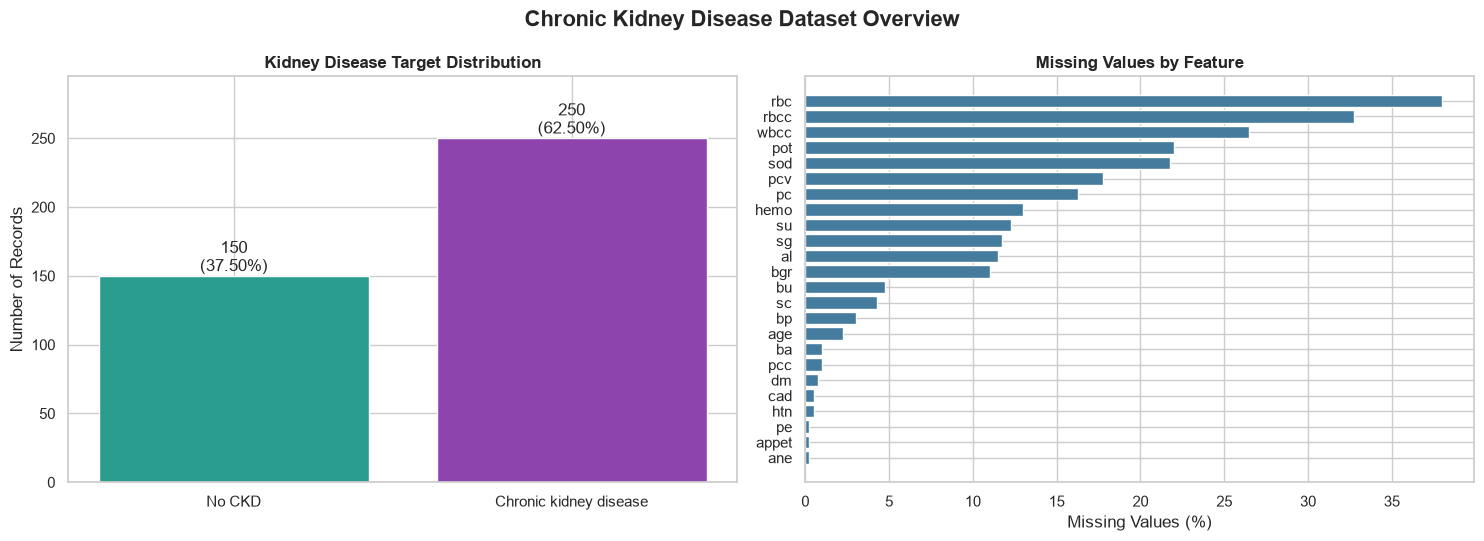

Overview figure saved: True
Overview figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\kidney_dataset_overview.png


In [7]:
# Create the target distribution chart
target_counts = (
    kidney_clean["kidney_disease"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_counts
    .div(target_counts.sum())
    .mul(100)
)

figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))

target_colors = ["#2A9D8F", "#8E44AD"]
target_labels = ["No CKD", "Chronic kidney disease"]

bars = axes[0].bar(
    target_labels,
    target_counts.values,
    color=target_colors
)

for bar, count, percentage in zip(
    bars,
    target_counts.values,
    target_percentages.values
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

axes[0].set_title("Kidney Disease Target Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Records")
axes[0].set_ylim(0, target_counts.max() * 1.18)

# Create the missing-value percentage chart
missing_percentages = (
    kidney_clean.drop(columns=["kidney_disease"])
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

axes[1].barh(
    missing_percentages.index,
    missing_percentages.values,
    color="#457B9D"
)

axes[1].set_title("Missing Values by Feature", fontweight="bold")
axes[1].set_xlabel("Missing Values (%)")

figure.suptitle(
    "Chronic Kidney Disease Dataset Overview",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

overview_figure_path = figures_folder / "kidney_dataset_overview.png"
plt.savefig(overview_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Overview figure saved:", overview_figure_path.exists())
print("Overview figure path:", overview_figure_path)

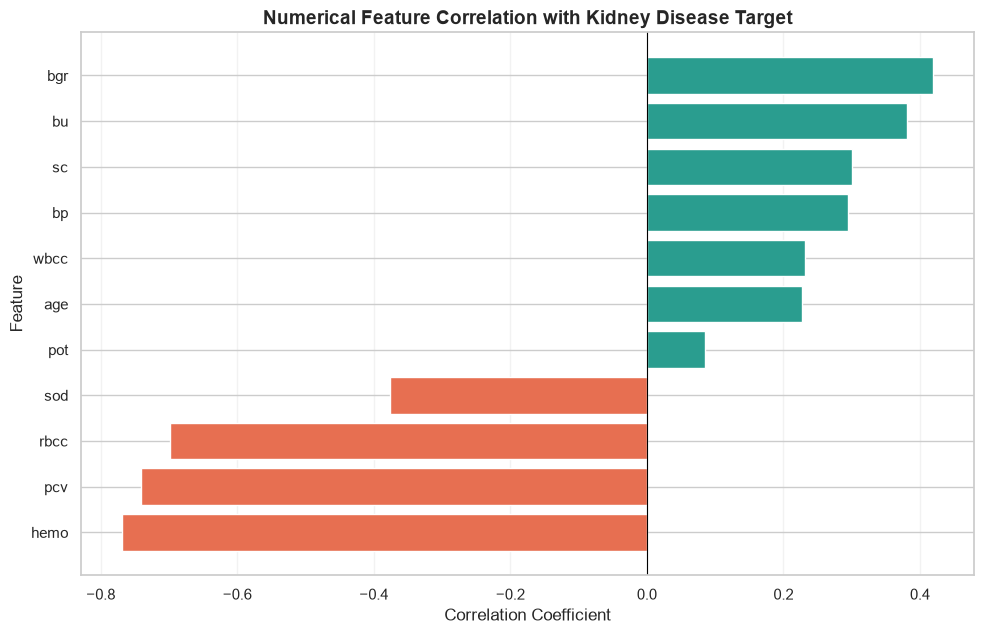

,Correlation
hemo,-0.7689
pcv,-0.7414
rbcc,-0.6991
sod,-0.3757
pot,0.0845
age,0.2273
wbcc,0.2319
bp,0.2941
sc,0.3000
bu,0.3806


Correlation figure saved: True


In [8]:
# Calculate numerical correlations with the binary target
available_numerical_columns = [
    column
    for column in numerical_columns
    if column in kidney_clean.columns
]

numerical_correlations = (
    kidney_clean[available_numerical_columns + ["kidney_disease"]]
    .corr(numeric_only=True)["kidney_disease"]
    .drop("kidney_disease")
    .sort_values()
)

correlation_colors = [
    "#E76F51" if value < 0 else "#2A9D8F"
    for value in numerical_correlations.values
]

plt.figure(figsize=(10, 6.5))
plt.barh(
    numerical_correlations.index,
    numerical_correlations.values,
    color=correlation_colors
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Numerical Feature Correlation with Kidney Disease Target",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

correlation_figure_path = figures_folder / "kidney_numeric_correlations.png"
plt.savefig(correlation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

display(numerical_correlations.to_frame("Correlation").round(4))
print("Correlation figure saved:", correlation_figure_path.exists())

In [9]:
# Save missing values without imputation to prevent data leakage
kidney_clean.to_csv(
    processed_data_path,
    index=False
)

# Reload the file to verify the saved output
saved_kidney_data = pd.read_csv(processed_data_path)

print("Processed file saved:", processed_data_path.exists())
print("Processed file path:", processed_data_path)
print("Saved dataset shape:", saved_kidney_data.shape)
print("Saved target values:", sorted(saved_kidney_data["kidney_disease"].unique()))
print("Total remaining missing values:", saved_kidney_data.isnull().sum().sum())

Processed file saved: True
Processed file path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\kidney_disease_clean.csv
Saved dataset shape: (400, 25)
Saved target values: [np.int64(0), np.int64(1)]
Total remaining missing values: 1013


## Interpretation notes

- Missing values remain intentionally and must be imputed inside a machine-learning pipeline after the train/validation/test split.
- Correlation describes linear association and does not establish causation or complete model importance.
- The dataset contains only 400 records, so final performance estimates should be interpreted cautiously.
- The future application must present its output as educational screening rather than medical diagnosis.

### Required attribution
Rubini, L., Soundarapandian, P., & Eswaran, P. (2015). *Chronic Kidney Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020